# License Plate Detector
Run this notebook top-to-bottom. It will scan the `watch_videos/` folder,
process every video file it finds, and save results to a Parquet file.

**Detection:** Yolov8-ANPR (plate-specific model), trained on the ANPR dataset.
**Dedup:** fuzzy matching (edit distance) collapses near-identical OCR reads into one record.
**Filtering:** minimum 6-character plates, minimum 50% OCR confidence.


## 1 — Install dependencies
Run once. Restart the kernel afterwards if prompted.

In [19]:
import sys
!{sys.executable} -m pip install opencv-python easyocr numpy pandas pyarrow ultralytics --quiet
import sys
!{sys.executable} -m pip install roboflow --quiet
print('All packages installed.')


All packages installed.


## 2 — Imports & configuration

In [20]:
import cv2
import easyocr
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import base64
import re
import os
from datetime import datetime, timedelta
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, HTML

# ── Configuration — edit these as needed ──────────────────────────────────

# Folder containing your video files
VIDEO_FOLDER    = './watch_videos'

# Parquet file where detections are stored
PARQUET_FILE    = './plate_detections.parquet'

# Only re-record the same plate after this many minutes
DEDUP_MINUTES   = 15

# Fuzzy dedup: treat two plates as the same if they differ by this many
# characters or fewer (edit distance). Set to 0 to disable fuzzy matching.
FUZZY_THRESHOLD = 4

# Minimum OCR confidence to accept a reading (raised to cut noise)
MIN_CONFIDENCE  = 0.5

# Minimum YOLO detection confidence
YOLO_CONF       = 0.15

# Minimum plate character length (raised to filter out fragments)
MIN_PLATE_LEN   = 7

# Maximum plate character length
MAX_PLATE_LEN   = 10

# Analyse every Nth frame (5 = good balance of speed vs coverage)
FRAME_SKIP      = 2

# Asymmetric padding around each detected plate box before OCR
# Left gets more padding to capture characters YOLO misses on the left edge
LEFT_CROP_PADDING   = 60
RIGHT_CROP_PADDING  = 15
TOP_CROP_PADDING    = 10
BOTTOM_CROP_PADDING = 10

# Save annotated debug frames to help diagnose missed detections
DEBUG_MODE      = False
DEBUG_FOLDER    = './debug_frames'

VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv', '.wmv'}

print('Configuration loaded.')
print(f'  Video folder    : {os.path.abspath(VIDEO_FOLDER)}')
print(f'  Parquet file    : {os.path.abspath(PARQUET_FILE)}')
print(f'  Dedup window    : {DEDUP_MINUTES} minutes')
print(f'  Fuzzy threshold : {FUZZY_THRESHOLD} chars')
print(f'  Min confidence  : {MIN_CONFIDENCE:.0%}')
print(f'  Min plate len   : {MIN_PLATE_LEN} chars')
print(f'  Crop padding    : L={LEFT_CROP_PADDING} R={RIGHT_CROP_PADDING} T={TOP_CROP_PADDING} B={BOTTOM_CROP_PADDING}')


Configuration loaded.
  Video folder    : c:\School Git\Rich_Fox_-_AI-Portfolio\Computer Vision\Object_Detection_Project\Notebooks\watch_videos
  Parquet file    : c:\School Git\Rich_Fox_-_AI-Portfolio\Computer Vision\Object_Detection_Project\Notebooks\plate_detections.parquet
  Dedup window    : 15 minutes
  Fuzzy threshold : 4 chars
  Min confidence  : 50%
  Min plate len   : 7 chars
  Crop padding    : L=60 R=15 T=10 B=10


## 3 — Storage helpers

In [21]:
SCHEMA = pa.schema([
    pa.field('timestamp',   pa.string()),
    pa.field('plate_text',  pa.string()),
    pa.field('confidence',  pa.float32()),
    pa.field('source_file', pa.string()),
    pa.field('plate_image', pa.string()),
])


def _load_existing() -> pd.DataFrame:
    if os.path.exists(PARQUET_FILE):
        return pd.read_parquet(PARQUET_FILE)
    return pd.DataFrame(columns=['timestamp', 'plate_text', 'confidence',
                                  'source_file', 'plate_image'])


def _save(df: pd.DataFrame):
    table = pa.Table.from_pandas(df, schema=SCHEMA, preserve_index=False)
    pq.write_table(table, PARQUET_FILE, compression='snappy')


def _edit_distance(a: str, b: str) -> int:
    """
    Levenshtein edit distance between two strings.
    Counts the minimum insertions, deletions, and substitutions
    needed to turn string a into string b.
    """
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    if not b:
        return len(a)
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a):
        curr = [i + 1]
        for j, cb in enumerate(b):
            curr.append(min(
                prev[j + 1] + 1,       # deletion
                curr[j] + 1,           # insertion
                prev[j] + (ca != cb)   # substitution
            ))
        prev = curr
    return prev[-1]


def is_duplicate(plate_text: str) -> bool:
    """
    Return True if a sufficiently similar plate was recorded
    within the last DEDUP_MINUTES.
    'Sufficiently similar' means edit distance <= FUZZY_THRESHOLD.
    """
    df = _load_existing()
    if df.empty:
        return False
    df = df.copy()
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    cutoff  = datetime.now() - timedelta(minutes=DEDUP_MINUTES)
    recent  = df[df['timestamp'] >= cutoff]
    if recent.empty:
        return False
    plate_up = plate_text.upper()
    for existing in recent['plate_text']:
        if _edit_distance(plate_up, existing) <= FUZZY_THRESHOLD:
            return True
    return False


def save_detection(plate_text: str, confidence: float,
                   crop_bgr: np.ndarray, source_file: str):
    _, buf = cv2.imencode('.png', crop_bgr)
    b64    = base64.b64encode(buf.tobytes()).decode('utf-8')
    ts     = datetime.now().isoformat(timespec='seconds')
    row    = {
        'timestamp':   ts,
        'plate_text':  plate_text.upper(),
        'confidence':  round(float(confidence), 4),
        'source_file': os.path.basename(source_file),
        'plate_image': b64,
    }
    df = _load_existing()
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    _save(df)
    print(f'  Saved  {plate_text.upper()}  ({confidence:.0%})  @ {ts}')


print('Storage helpers ready.')


Storage helpers ready.


## 4 — Load models
YOLOv8 nano (~6 MB) downloads automatically on first run.


In [22]:
# Download the Yolov8-ANPR model from Roboflow (run once)
# Requires: pip install roboflow (already included in install cell)
# Replace 'your-api-key' with your Roboflow API key
#
from roboflow import Roboflow
rf = Roboflow(api_key='CTwanlAyVZj9zagBTqB7')
project = rf.workspace('license-plate-detection-chetl').project('yolov8-anpr')
version = project.version(1)
dataset = version.download('yolov8')
# After downloading, the model weights will be at:
# ./yolov8-anpr-1/weights/best.pt

# Path to ANPR model weights — update if your download path differs
ANPR_MODEL_PATH = './runs/detect/anpr_training/run1/weights/best.pt'

# Fall back to general yolov8n if ANPR model not yet downloaded
if os.path.exists(ANPR_MODEL_PATH):
    print(f'Loading ANPR model: {ANPR_MODEL_PATH}')
    _yolo = YOLO(ANPR_MODEL_PATH)
    print('ANPR model ready.')
else:
    print(f'ANPR model not found at {ANPR_MODEL_PATH}')
    print('Falling back to general yolov8n.pt')
    print('Download the ANPR model using the commented code above.')
    _yolo = YOLO('yolov8n.pt')
    print('Fallback model ready.')

print('Loading EasyOCR model (first run ~30 s)...')
_reader = easyocr.Reader(['en'], gpu=False)
print('EasyOCR ready.')


loading Roboflow workspace...
loading Roboflow project...


Using CPU. Note: This module is much faster with a GPU.


Loading ANPR model: ./runs/detect/anpr_training/run1/weights/best.pt
ANPR model ready.
Loading EasyOCR model (first run ~30 s)...
EasyOCR ready.


## 4b — Train ANPR model
Run this cell **once** to train YOLOv8 on the ANPR dataset.
Training takes ~30-60 minutes on CPU, ~5 minutes on GPU.
It will be skipped automatically if trained weights already exist.


In [23]:
# ── ANPR Training ─────────────────────────────────────────────────────────
# This cell trains YOLOv8 on the ANPR dataset.
# It will ONLY run if:
#   (a) ANPR_MODEL_PATH points to the trained weights location, AND
#   (b) those weights do not yet exist
# If you are using the fallback yolov8n.pt, training is skipped entirely.

from ultralytics import YOLO as _YOLO_train

TRAINED_WEIGHTS = './anpr_training/run1/weights/best.pt'
DATA_YAML       = './Yolov8-ANPR-1/data.yaml'

# Only attempt training if ANPR_MODEL_PATH refers to the trained weights
_using_anpr = (ANPR_MODEL_PATH == TRAINED_WEIGHTS)

if not _using_anpr:
    print('Not using ANPR model path — training skipped.')
    print(f'Current ANPR_MODEL_PATH: {ANPR_MODEL_PATH}')
    print('Change ANPR_MODEL_PATH in the config cell if you want to train.')
elif os.path.exists(TRAINED_WEIGHTS):
    print(f'Trained weights already found at: {TRAINED_WEIGHTS}')
    print('Skipping training. Delete the file above to retrain from scratch.')
elif not os.path.exists(DATA_YAML):
    print(f'Training data not found at: {DATA_YAML}')
    print('Please download the dataset first using the Roboflow code in the model cell above.')
else:
    print(f'Training data found: {DATA_YAML}')
    print('Starting training — this will take 30-60 mins on CPU...')
    _model = _YOLO_train('yolov8n.pt')
    _model.train(
        data=DATA_YAML,
        epochs=30,
        imgsz=640,
        project='./anpr_training',
        name='run1',
        exist_ok=True,
    )
    if os.path.exists(TRAINED_WEIGHTS):
        print(f'Training complete. Weights saved to: {TRAINED_WEIGHTS}')
    else:
        print('Training finished but weights not found — check for errors above.')


Not using ANPR model path — training skipped.
Current ANPR_MODEL_PATH: ./runs/detect/anpr_training/run1/weights/best.pt
Change ANPR_MODEL_PATH in the config cell if you want to train.


## 5 — Detection engine

In [24]:
def _enhance_crop(roi: np.ndarray) -> np.ndarray:
    """Upscale, boost contrast, and sharpen a plate crop before OCR."""
    h, w = roi.shape[:2]
    scale = max(1, 200 // max(h, 1))
    if scale > 1:
        roi = cv2.resize(roi, (w * scale, h * scale), interpolation=cv2.INTER_CUBIC)
    gray     = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    gray     = clahe.apply(gray)
    blurred  = cv2.GaussianBlur(gray, (0, 0), 3)
    sharp    = cv2.addWeighted(gray, 1.8, blurred, -0.8, 0)
    denoised = cv2.fastNlMeansDenoising(sharp, h=10)
    return cv2.cvtColor(denoised, cv2.COLOR_GRAY2BGR)


def _get_plate_boxes(frame: np.ndarray) -> list:
    """Run YOLO and return boxes with a plate-like aspect ratio."""
    results = _yolo(frame, conf=YOLO_CONF, verbose=False)[0]
    boxes   = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        bw, bh = x2 - x1, y2 - y1
        if bh > 0 and 1.5 <= (bw / bh) <= 7.0:
            boxes.append((x1, y1, x2, y2))
    return boxes


def _clean(text: str) -> str:
    return re.sub(r'[^A-Z0-9]', '', text.upper())


# Pattern now uses MIN_PLATE_LEN and MAX_PLATE_LEN from config
def _is_valid_plate(text: str) -> bool:
    return bool(re.match(r'^[A-Z0-9]+$', text)) and MIN_PLATE_LEN <= len(text) <= MAX_PLATE_LEN


def process_video(video_path: str):
    """Process a single video file and save any detected plates."""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f'  Cannot open: {video_path}')
        return

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS) or 30
    print(f'  {os.path.basename(video_path)}  |  {total} frames  |  {fps:.0f} fps')

    frame_idx     = 0
    found         = 0
    seen_this_run = set()  # exact matches already handled this run

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frame_idx += 1
        if frame_idx % FRAME_SKIP != 0:
            continue

        boxes = _get_plate_boxes(frame)

        if DEBUG_MODE and frame_idx % (FRAME_SKIP * 30) == 0:
            os.makedirs(DEBUG_FOLDER, exist_ok=True)
            vis = frame.copy()
            for (x1, y1, x2, y2) in boxes:
                cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
            name = f'{Path(video_path).stem}_frame{frame_idx:05d}.jpg'
            cv2.imwrite(os.path.join(DEBUG_FOLDER, name), vis)

        h_f, w_f = frame.shape[:2]
        for (x1, y1, x2, y2) in boxes:
            x1p = max(0, x1 - LEFT_CROP_PADDING)
            y1p = max(0, y1 - TOP_CROP_PADDING)
            x2p = min(w_f, x2 + RIGHT_CROP_PADDING)
            y2p = min(h_f, y2 + BOTTOM_CROP_PADDING)
            crop     = frame[y1p:y2p, x1p:x2p]
            enhanced = _enhance_crop(crop)
            readings = _reader.readtext(enhanced)
            for (_, text, conf) in readings:
                if conf < MIN_CONFIDENCE:
                    continue
                clean = _clean(text)
                if not _is_valid_plate(clean):
                    continue
                # Skip if an exact or fuzzy match was already seen this run
                already_seen = any(
                    _edit_distance(clean, s) <= FUZZY_THRESHOLD
                    for s in seen_this_run
                )
                if already_seen:
                    continue
                if is_duplicate(clean):
                    print(f'  Skipped (fuzzy dedup, {DEDUP_MINUTES}-min window): {clean}')
                    seen_this_run.add(clean)
                    continue
                save_detection(clean, conf, crop, video_path)
                seen_this_run.add(clean)
                found += 1

    cap.release()
    print(f'  Done  -  {found} new plate(s) recorded.\n')


print('Detection engine ready.')


Detection engine ready.


## 6 — Process all videos in the folder
Drop your video files into `watch_videos/` then run this cell.


In [28]:
os.makedirs(VIDEO_FOLDER, exist_ok=True)

video_files = [
    f for f in sorted(Path(VIDEO_FOLDER).iterdir())
    if f.suffix.lower() in VIDEO_EXTENSIONS
]

if not video_files:
    print(f'No video files found in: {os.path.abspath(VIDEO_FOLDER)}')
    print(f'Supported formats: {", ".join(VIDEO_EXTENSIONS)}')
else:
    print(f'Found {len(video_files)} video file(s):\n')
    for vf in video_files:
        print(f'Processing: {vf.name}')
        process_video(str(vf))
    print('All videos processed.')


Found 4 video file(s):

Processing: 13110293_1280_720_30fps.mp4
  13110293_1280_720_30fps.mp4  |  696 frames  |  30 fps


'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


  Saved  MHOZOOSSC  (53%)  @ 2026-05-08T15:17:01


'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


  Done  -  1 new plate(s) recorded.

Processing: 15330191_720_1280_60fps.mp4
  15330191_720_1280_60fps.mp4  |  556 frames  |  60 fps
  Saved  6403401095  (54%)  @ 2026-05-08T15:19:30


...

  Saved  KYP6964  (61%)  @ 2026-05-08T15:58:55


'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


  Saved  ZOIAMOIOIS  (62%)  @ 2026-05-08T15:59:21


'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.


  Done  -  3 new plate(s) recorded.

All videos processed.


## 7 — View all recorded detections

In [29]:
def view_detections(show_images: bool = True, max_rows: int = 50):
    """
    Display all detections stored in the Parquet file.

    Parameters
    ----------
    show_images : bool
        Render the plate crop next to each row (default True).
    max_rows : int
        Maximum rows to show, most recent first (default 50).
    """
    df = _load_existing()
    if df.empty:
        print('No detections recorded yet.')
        return

    df    = df.sort_values('timestamp', ascending=False).head(max_rows).reset_index(drop=True)
    total = len(_load_existing())
    print(f'Showing {len(df)} of {total} total detection(s)   |   {PARQUET_FILE}\n')

    if show_images:
        header = (
            '<tr>'
            '<th>Timestamp</th>'
            '<th>Plate</th>'
            '<th>Confidence</th>'
            '<th>Source file</th>'
            '<th>Crop</th>'
            '</tr>'
        )
        rows_html = ''
        for i, row in df.iterrows():
            try:
                img_tag = (
                    '<img src="data:image/png;base64,' + row['plate_image'] + '" '
                    'style="height:38px;border-radius:3px;" />'
                )
            except Exception:
                img_tag = 'n/a'
            conf_pct = f"{float(row['confidence']):.0%}"
            bg       = '#fafafa' if i % 2 == 0 else '#ffffff'
            rows_html += (
                f"<tr style='background:{bg}'>"
                f"<td style='padding:6px 10px'>{row['timestamp']}</td>"
                f"<td style='padding:6px 10px;font-weight:700;letter-spacing:1px'>{row['plate_text']}</td>"
                f"<td style='padding:6px 10px'>{conf_pct}</td>"
                f"<td style='padding:6px 10px'>{row['source_file']}</td>"
                f"<td style='padding:6px 4px'>{img_tag}</td>"
                '</tr>'
            )
        style = (
            '<style>'
            '.plt{border-collapse:collapse;font-family:sans-serif;font-size:13px;width:100%}'
            '.plt th{background:#efefef;padding:8px 10px;text-align:left;border-bottom:2px solid #ccc}'
            '.plt tr:hover{background:#eef4ff!important}'
            '</style>'
        )
        html = style + "<table class='plt'>" + header + '<tbody>' + rows_html + '</tbody></table>'
        display(HTML(html))
    else:
        show_df = df[['timestamp', 'plate_text', 'confidence', 'source_file']].copy()
        show_df['confidence'] = show_df['confidence'].map(lambda x: f"{float(x):.0%}")
        display(
            show_df.style
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([{'selector': 'th',
                                'props': [('background-color', '#efefef'),
                                          ('font-weight', 'bold'),
                                          ('text-align', 'left')]}])
            .hide(axis='index')
        )


print('view_detections() is ready.')
print()
print('Usage:')
print('  view_detections()                   # table with plate images (default)')
print('  view_detections(show_images=False)  # plain styled table, no images')
print('  view_detections(max_rows=200)       # show more rows')


view_detections() is ready.

Usage:
  view_detections()                   # table with plate images (default)
  view_detections(show_images=False)  # plain styled table, no images
  view_detections(max_rows=200)       # show more rows


### Run to display your data

Showing 21 of 21 total detection(s)   |   ./plate_detections.parquet



Timestamp,Plate,Confidence,Source file,Crop
2026-05-08T15:59:21,ZOIAMOIOIS,62%,MVI_1407.MOV,
2026-05-08T15:58:55,KYP6964,61%,MVI_1407.MOV,
2026-05-08T15:58:09,NBG5722,62%,MVI_1407.MOV,
2026-05-08T15:57:36,TRSTORE,60%,IMG_4440.mov,
2026-05-08T15:56:22,LIQUORSTOR,65%,IMG_4440.mov,
2026-05-08T15:56:22,BIGBOTTLE,72%,IMG_4440.mov,
2026-05-08T15:51:16,VDD6950,52%,IMG_4440.mov,
2026-05-08T15:47:19,KXDK0932,52%,IMG_4440.mov,
2026-05-08T15:42:51,KRV1781,72%,IMG_4440.mov,
2026-05-08T15:42:12,HJH5924,69%,IMG_4440.mov,

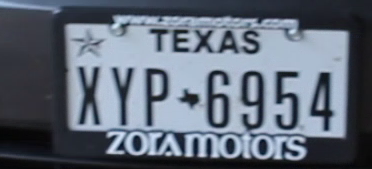
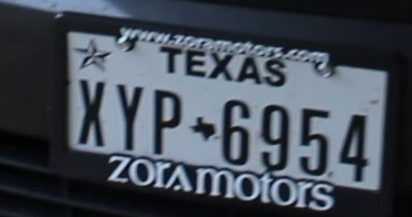
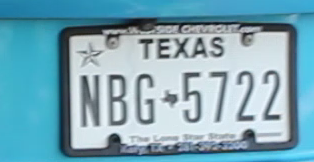
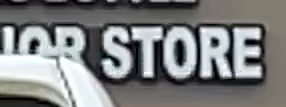
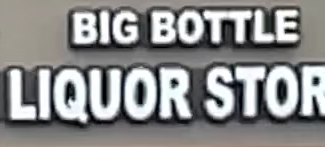
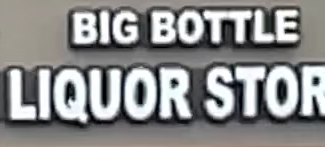
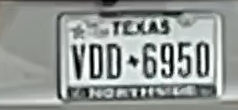
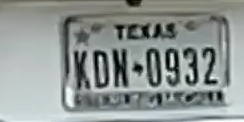
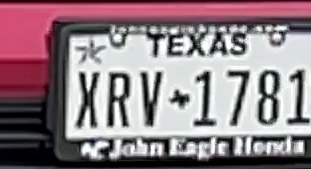
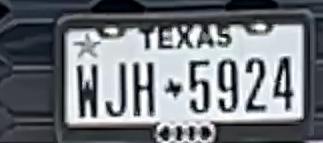
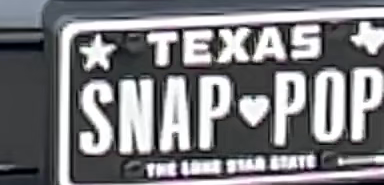
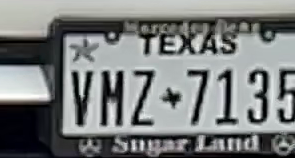
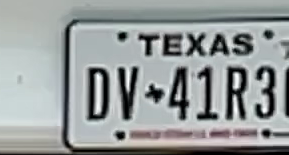
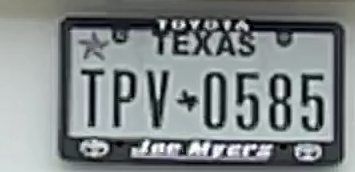
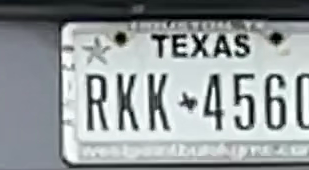
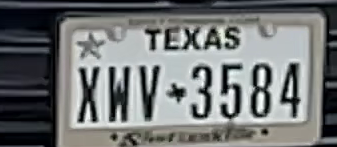
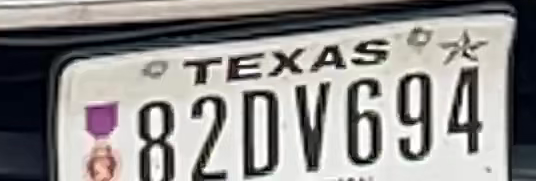
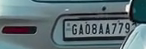
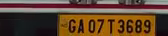
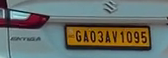
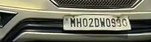

In [30]:
view_detections()
